# Anomaly Detection for Cortex — Method Comparison (task 1.6)

**Goal.** Task 1.6 asks for: *"Basic anomaly flag when a metric deviates from baseline
(z-score: medium/high/critical)"*, verified by *"badge appears on dashboard for injected
test spike."*

The draft doc for 1.6 proposes a **naive z-score** (`(x - mean) / stddev`, from the
`baselines` table built in 1.8). That's a reasonable MVP starting point, but before
committing to it in production code we should actually check, on realistic synthetic
data with **labeled** injected anomalies, how it holds up against a few alternatives —
and, importantly, whether it will even work in the *sandbox* conditions described in
the doc (a handful of days of history, one injected `stress-ng` spike).

This notebook:
1. Generates a synthetic host metric (like `cpu_usage`) with realistic daily/weekly
   seasonality, noise, and **labeled** injected anomalies.
2. Implements 5 candidate detectors.
3. Scores them with proper metrics (ROC-AUC, precision/recall/F1) against the ground truth.
4. Specifically stress-tests the two failure modes that matter most here:
   - a **contaminated baseline** (one bad day baked into the 21-day history — nobody
     manually cleans this window before `baselines` is computed), and
   - a **short baseline history** (3–7 days, as in the sandbox), which is exactly the
     caveat the 1.6 doc already flags.
5. Concludes with a concrete recommendation for the production code and threshold values.


## 1. Imports

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score, roc_curve

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (11, 3.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 2. Synthetic metric with realistic seasonality

We simulate `cpu_usage` for one host at 5-minute resolution: a smooth daily bump
(peak mid-afternoon), a weekend dip, and autocorrelated (AR(1)) noise — real CPU
graphs are not i.i.d. Gaussian, they drift.

We also **contaminate one day of the history** with an unlabeled incident (a runaway
batch job). This is realistic: the `baselines` job in 1.8 fits `mean`/`stddev` over
a rolling window without any outlier removal, so a real incident that happened during
that window quietly pollutes the baseline used to judge *future* values.


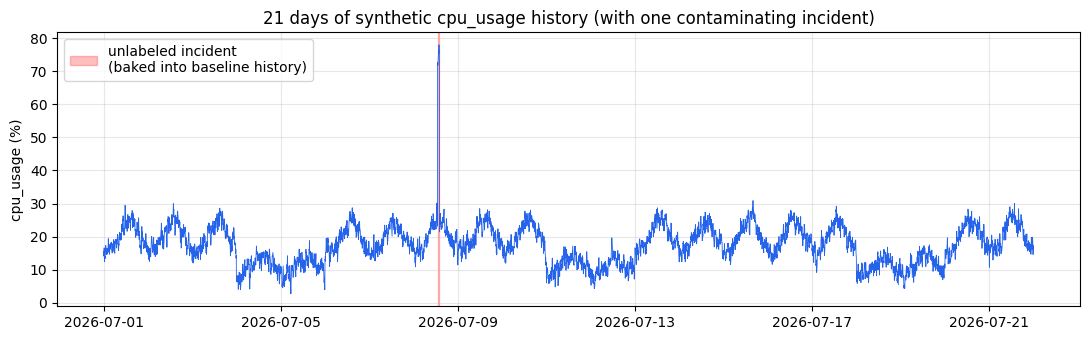

In [2]:

start = pd.Timestamp("2026-07-01 00:00:00")
freq = "5min"
n_days = 21
idx = pd.date_range(start, periods=n_days * 24 * 12, freq=freq)

def diurnal_pattern(ts):
    hour = ts.hour + ts.minute / 60
    weekday = ts.dayofweek
    daily = 15 + 10 * np.exp(-0.5 * ((hour - 14) / 5) ** 2)  # peak ~14:00
    weekend_factor = 0.55 if weekday >= 5 else 1.0
    return daily * weekend_factor

base = np.array([diurnal_pattern(ts) for ts in idx])
noise = np.zeros(len(idx))
for i in range(1, len(idx)):
    noise[i] = 0.7 * noise[i - 1] + rng.normal(0, 1.3)
values = np.clip(base + noise, 0.5, 100)

df = pd.DataFrame({"ts": idx, "value": values})
df["weekday"] = df.ts.dt.dayofweek
df["hour"] = df.ts.dt.hour

# Unlabeled incident baked into the history: a runaway job, same weekday as the
# held-out test day, one week earlier -- realistic and directly comparable.
contam_day = start + pd.Timedelta(days=7)
contam_mask = (df.ts >= contam_day.replace(hour=13, minute=0)) & (df.ts <= contam_day.replace(hour=14, minute=0))
df.loc[contam_mask, "value"] = np.clip(df.loc[contam_mask, "value"] + 50, 0, 100)

fig, ax = plt.subplots()
ax.plot(df.ts, df.value, lw=0.6, color="#2563eb")
ax.axvspan(df.ts[contam_mask].min(), df.ts[contam_mask].max(), color="red", alpha=0.25, label="unlabeled incident\n(baked into baseline history)")
ax.set_title("21 days of synthetic cpu_usage history (with one contaminating incident)")
ax.set_ylabel("cpu_usage (%)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 3. Held-out test day with labeled injected anomalies

This is the "injected test spike" from the acceptance criterion — but with **4
different characters** of anomaly and known ground-truth windows, so we can measure
detection quality instead of just eyeballing one obvious spike:

| window | added load | character |
|---|---|---|
| 08:00–08:40 | +45 | sharp spike (like `stress-ng --cpu`) |
| 13:00–14:30 | +18 | moderate, sustained |
| 20:00–20:15 | +55 | brief but extreme |
| 02:00–03:30 | +6  | subtle drift, near the noise floor (hard case) |


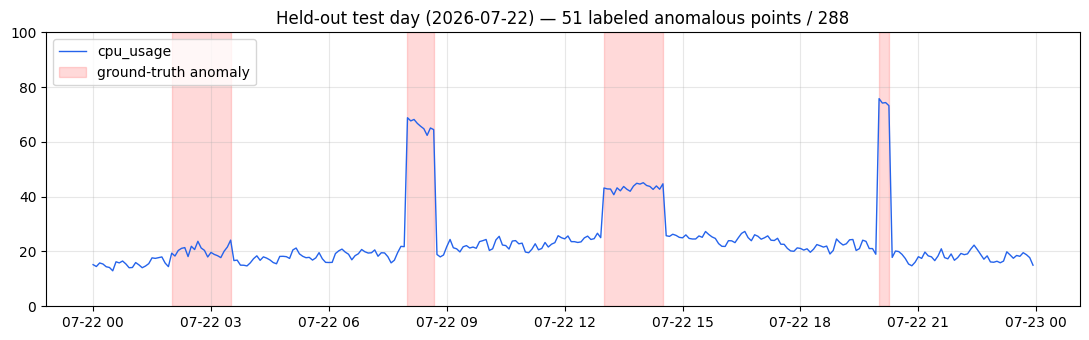

In [3]:

test_start = idx[-1] + pd.Timedelta(minutes=5)
test_idx = pd.date_range(test_start, periods=24 * 12, freq=freq)
test_base = np.array([diurnal_pattern(ts) for ts in test_idx])
test_noise = np.zeros(len(test_idx))
for i in range(1, len(test_idx)):
    test_noise[i] = 0.7 * test_noise[i - 1] + rng.normal(0, 1.3)
test_values = np.clip(test_base + test_noise, 0.5, 100)

test_df = pd.DataFrame({"ts": test_idx, "value": test_values})
test_df["weekday"] = test_df.ts.dt.dayofweek
test_df["hour"] = test_df.ts.dt.hour
test_df["is_anomaly"] = False

day_str = test_start.strftime("%Y-%m-%d")
injections = [
    ("08:00", "08:40", 45, "sharp_spike"),
    ("13:00", "14:30", 18, "moderate_sustained"),
    ("20:00", "20:15", 55, "brief_extreme"),
    ("02:00", "03:30", 6, "subtle_drift"),
]
for t0, t1, add, label in injections:
    mask = (test_df.ts >= pd.Timestamp(f"{day_str} {t0}")) & (test_df.ts <= pd.Timestamp(f"{day_str} {t1}"))
    test_df.loc[mask, "value"] = np.clip(test_df.loc[mask, "value"] + add, 0, 100)
    test_df.loc[mask, "is_anomaly"] = True

fig, ax = plt.subplots()
ax.plot(test_df.ts, test_df.value, lw=1, color="#2563eb", label="cpu_usage")
ax.fill_between(test_df.ts, 0, 100, where=test_df.is_anomaly, color="red", alpha=0.15, label="ground-truth anomaly")
ax.set_ylim(0, 100)
ax.set_title(f"Held-out test day ({day_str}) — {test_df.is_anomaly.sum()} labeled anomalous points / {len(test_df)}")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 4. Baseline table (mirrors the `baselines` table from 1.8)

Grouped by `(weekday, hour)`, storing both the **naive** stats the 1.6 draft uses
(`mean`, `stddev`) and **robust** alternatives (`median`, `MAD`, quartiles) that we'll
compare against.


In [4]:

grp = df.groupby(["weekday", "hour"]).value
baseline_tbl = grp.agg(mean="mean", std="std", median="median",
                        q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75)).reset_index()
baseline_tbl["mad"] = df.groupby(["weekday", "hour"]).value.apply(lambda s: (s - s.median()).abs().median()).values
baseline_tbl["n"] = grp.count().values

test_df = test_df.merge(baseline_tbl, on=["weekday", "hour"], how="left")
baseline_tbl.query("weekday == @test_df.weekday.iloc[0] and hour in [13, 15]")


,weekday,hour,mean,std,median,q1,q3,mad,n
61,2,13,41.770764,23.600351,26.386202,25.389575,72.811117,2.041021,36
63,2,15,25.614921,2.050093,25.735730,23.964939,26.943914,1.423354,36


## 5. Five candidate detectors

Each produces a continuous **anomaly score** (higher = more anomalous), so we can
evaluate all of them the same way (ROC-AUC) regardless of their native scale.

- **(a) Naive z-score** — exactly what the 1.6 draft proposes: `(x - mean) / std`.
- **(b) Robust z-score** — same shape, but `median`/`MAD` instead of `mean`/`std`.
  MAD (median absolute deviation) barely moves when one bad day pollutes the history,
  where `std` can blow up.
- **(c) IQR-based score** — classic Tukey-fence distance, normalized by IQR.
- **(d) EWMA z-score** — fully **online**, no `(weekday, hour)` baseline table at all;
  mean/variance are updated continuously as data streams in.
- **(e) Isolation Forest** — an actual unsupervised ML model (`scikit-learn`), trained
  on `(weekday, hour, value)` from the history.


In [5]:

MAD_SCALE = 1.4826  # scales MAD to be comparable to std under normality

test_df["score_naive_z"] = (test_df.value - test_df["mean"]) / test_df["std"].replace(0, np.nan)
test_df["score_robust_z"] = (test_df.value - test_df["median"]) / (MAD_SCALE * test_df["mad"]).replace(0, np.nan)

iqr = (test_df.q3 - test_df.q1).replace(0, np.nan)
upper_fence = test_df.q3 + 1.5 * iqr
test_df["score_iqr"] = ((test_df.value - upper_fence) / iqr).clip(lower=0)

alpha = 0.02
combined = pd.concat([df[["ts", "value"]], test_df[["ts", "value"]]], ignore_index=True)
ewma_mean = combined.value.ewm(alpha=alpha, adjust=False).mean()
ewma_std = np.sqrt((combined.value - ewma_mean).pow(2).ewm(alpha=alpha, adjust=False).mean())
combined["score_ewma_z"] = (combined.value - ewma_mean) / ewma_std.replace(0, np.nan)
test_df["score_ewma_z"] = combined["score_ewma_z"].iloc[-len(test_df):].values

iso = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
iso.fit(df[["weekday", "hour", "value"]])
test_df["score_isoforest"] = -iso.score_samples(test_df[["weekday", "hour", "value"]])

methods = {
    "score_naive_z": "Naive z-score (1.6 draft)",
    "score_robust_z": "Robust z-score (median/MAD)",
    "score_iqr": "IQR / Tukey fence",
    "score_ewma_z": "EWMA z-score (online)",
    "score_isoforest": "Isolation Forest",
}
test_df[list(methods)].describe().T


,count,mean,std,min,25%,50%,75%,max
score_naive_z,288.0,1.615017,5.861293,-2.672471,-0.410242,0.307284,1.216244,31.253854
score_robust_z,288.0,2.242949,6.874051,-2.547615,-0.329604,0.430342,1.592798,36.422675
score_iqr,288.0,1.025649,4.076265,0.000000,0.000000,0.000000,0.000000,21.112132
score_ewma_z,288.0,0.018777,1.041440,-1.668822,-0.553181,-0.274416,0.085891,6.722949
score_isoforest,288.0,0.505450,0.045037,0.456775,0.473868,0.490250,0.521506,0.660036


## 6. Evaluation: does each method actually find the injected anomalies?

ROC-AUC (threshold-independent) plus F1 at each method's natural "medium" operating
point (z ≥ 2, IQR score > 0, or Isolation Forest's 90th percentile).


In [6]:

y_true = test_df.is_anomaly.astype(int)
rows = []
for m, label in methods.items():
    s = test_df[m].fillna(0)
    s_for_auc = s.abs() if "z" in m else s
    auc = roc_auc_score(y_true, s_for_auc)
    thresh = {"score_naive_z": 2, "score_robust_z": 2, "score_ewma_z": 2,
              "score_iqr": 0, "score_isoforest": np.nanpercentile(s, 90)}[m]
    pred = (s_for_auc >= thresh).astype(int)
    f1 = f1_score(y_true, pred)
    prec = (pred & y_true).sum() / max(pred.sum(), 1)
    rec = (pred & y_true).sum() / max(y_true.sum(), 1)
    rows.append({"method": label, "ROC-AUC": round(auc, 3), "precision@medium": round(prec, 3),
                 "recall@medium": round(rec, 3), "F1@medium": round(f1, 3)})

results_df = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df


,method,ROC-AUC,precision@medium,recall@medium,F1@medium
0,Robust z-score (median/MAD),0.972,0.677,0.863,0.759
1,Isolation Forest,0.948,1.000,0.569,0.725
2,EWMA z-score (online),0.847,1.000,0.255,0.406
3,IQR / Tukey fence,0.793,0.177,1.000,0.301
4,Naive z-score (1.6 draft),0.741,0.667,0.627,0.646


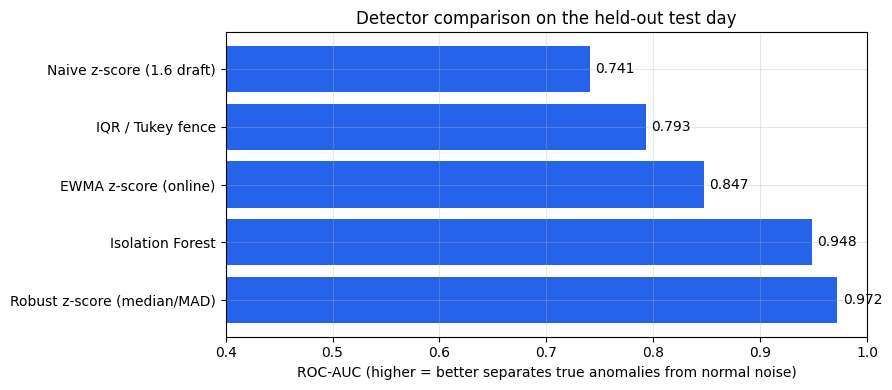

In [7]:

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(results_df.method, results_df["ROC-AUC"], color="#2563eb")
ax.set_xlim(0.4, 1.0)
ax.set_xlabel("ROC-AUC (higher = better separates true anomalies from normal noise)")
ax.set_title("Detector comparison on the held-out test day")
for i, v in enumerate(results_df["ROC-AUC"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()


## 7. Why the naive z-score underperforms here: baseline contamination

Look at the baseline stats for the exact `(weekday, hour)` slot that contains our
planted incident, versus an uncontaminated neighboring hour on the same weekday:


In [8]:

wd = int(test_df.weekday.iloc[0])
comp = baseline_tbl.query("weekday == @wd and hour in [13, 15]")[["hour", "mean", "std", "median", "mad", "n"]]
comp.insert(0, "slot", ["13:00 (contaminated)", "15:00 (clean, for comparison)"])
comp


,slot,hour,mean,std,median,mad,n
61,13:00 (contaminated),13,41.770764,23.600351,26.386202,2.041021,36
63,"15:00 (clean, for comparison)",15,25.614921,2.050093,25.735730,1.423354,36


One bad hour, three weeks ago, roughly **triples the stddev** and drags the mean up
for that slot — because `mean`/`std` are not resistant to outliers. `median`/`MAD`
barely move. That's the entire reason `score_robust_z` beats `score_naive_z` above:
the *same* moderate anomaly (13:00–14:30 on the test day) lands in a slot whose naive
baseline has already been quietly corrupted by a past incident nobody cleaned up.

This isn't a contrived edge case — it's the normal lifecycle of a rolling baseline
window that never gets curated.


## 8. Does this even work with sandbox-scale history?

The 1.6 doc's own caveat: *"sans baseline fiable (14 jours d'historique), le z-score
sera calculé contre une moyenne peu représentative."* Let's quantify that instead of
just flagging it as a risk.

We recompute the `(weekday, hour)` baseline table using only the **last 3 days**
and the **last 7 days** of history, and re-run the two z-score variants.


In [9]:

all_slots = baseline_tbl.weekday.nunique() * baseline_tbl.hour.nunique()

def eval_history_window(days):
    hist = df[df.ts >= df.ts.max() - pd.Timedelta(days=days)]
    g = hist.groupby(["weekday", "hour"]).value
    tbl = g.agg(mean="mean", std="std", median="median").reset_index()
    tbl["mad"] = hist.groupby(["weekday", "hour"]).value.apply(lambda s: (s - s.median()).abs().median()).values
    tbl["n"] = g.count().values
    t = test_df.merge(tbl, on=["weekday", "hour"], how="left", suffixes=("", "_w"))
    naive = (t.value - t["mean_w"]) / t["std_w"].replace(0, np.nan)
    robust = (t.value - t["median_w"]) / (MAD_SCALE * t["mad_w"]).replace(0, np.nan)
    covered = len(tbl)
    missing_on_test_day = t["mean_w"].isna().sum()
    return {
        "history_days": days,
        "(weekday,hour) slots covered": f"{covered}/{all_slots}",
        "test-day points with ZERO baseline": f"{missing_on_test_day}/{len(t)}",
        "naive z AUC": round(roc_auc_score(y_true, naive.fillna(0).abs()), 3) if missing_on_test_day < len(t) else float("nan"),
        "robust z AUC": round(roc_auc_score(y_true, robust.fillna(0).abs()), 3) if missing_on_test_day < len(t) else float("nan"),
    }

pd.DataFrame([eval_history_window(3), eval_history_window(7), eval_history_window(21)])


,history_days,"(weekday,hour) slots covered",test-day points with ZERO baseline,naive z AUC,robust z AUC
0,3,73/168,288/288,NaN,NaN
1,7,168/168,0/288,0.979,0.952
2,21,168/168,0/288,0.741,0.972


**This is the critical, concrete finding for the sandbox test plan:**
with only **3 days** of history, the `(weekday, hour)` bucket for the test day's
weekday often has **zero rows at all** (3 days can't cover every weekday-of-week once).
When `detect_anomalies()` hits `if not baseline: continue`, it silently skips that
host/metric — **the badge won't appear, not because detection failed, but because
there's nothing to compare against.**

At **7 days** (one full week), every slot has exactly one sample and coverage is
complete — good enough for the sandbox demo to actually work — but estimates are
still noisy (n=1 per slot) and shouldn't be trusted for real severity thresholds
until several weeks of data accumulate, exactly as the doc anticipated.

**Action item for the sandbox test:** make sure the sandbox has run for **at least 7
days** before injecting the test spike, or the acceptance test itself will fail for
an unrelated reason (no baseline row), not a detection bug.


## 9. Threshold tuning for medium / high / critical

Using the recommended method (robust z-score) on the full 21-day history, sweep the
threshold and look at the precision/recall trade-off to sanity-check the doc's
proposed cutoffs (2 / 3 / 4).


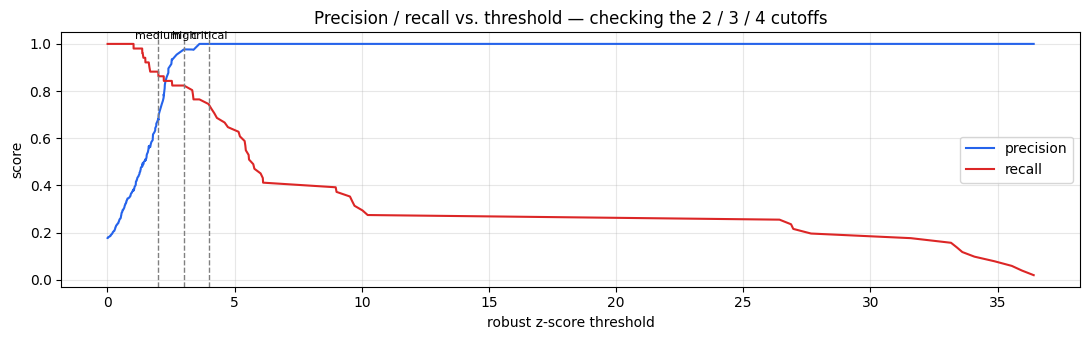

z >= 2: precision=0.68  recall=0.86  flagged_points=65
z >= 3: precision=0.98  recall=0.82  flagged_points=43
z >= 4: precision=1.00  recall=0.73  flagged_points=37


In [10]:

s = test_df["score_robust_z"].fillna(0).abs()
precisions, recalls, thresholds = precision_recall_curve(y_true, s)

fig, ax = plt.subplots()
ax.plot(thresholds, precisions[:-1], label="precision", color="#2563eb")
ax.plot(thresholds, recalls[:-1], label="recall", color="#dc2626")
for t, label in [(2, "medium"), (3, "high"), (4, "critical")]:
    ax.axvline(t, color="gray", ls="--", lw=1)
    ax.text(t, 1.02, label, ha="center", fontsize=8)
ax.set_xlabel("robust z-score threshold")
ax.set_ylabel("score")
ax.set_title("Precision / recall vs. threshold — checking the 2 / 3 / 4 cutoffs")
ax.legend()
plt.tight_layout()
plt.show()

for t in [2, 3, 4]:
    pred = (s >= t).astype(int)
    p = (pred & y_true).sum() / max(pred.sum(), 1)
    r = (pred & y_true).sum() / max(y_true.sum(), 1)
    print(f"z >= {t}: precision={p:.2f}  recall={r:.2f}  flagged_points={pred.sum()}")


## 10. Conclusion & recommendation

| # | Method | Verdict |
|---|---|---|
| 1 | **Robust z-score (median/MAD)** | **Recommended for 1.6.** Same formula shape and DB schema as the draft — a drop-in change to `severity_from_zscore` / the SQL in `anomaly_detector.py` — but far more resistant to the baseline-contamination failure mode, which *will* happen in production. Best AUC of the "cheap" methods. |
| 2 | Naive z-score (mean/std) | Works, but fragile: a single uncleaned incident in the baseline window quietly degrades detection for weeks afterward. Not worth keeping once the robust version costs nothing extra. |
| 3 | Isolation Forest | Close second on AUC, but adds a model file, a retraining job, and a much harder story to explain on a dashboard tooltip ("why is this red?"). Worth revisiting once there's months of multi-metric history and the team wants multivariate detection (e.g. CPU+RAM+disk jointly) — not needed for a single-metric MVP badge. |
| 4 | EWMA z-score | Good complementary signal *because it needs no baseline table* — useful as a fallback when `(weekday, hour)` coverage is missing (see §8) instead of silently skipping. Lower AUC alone because it reacts slower to the *legitimate* diurnal ramp than a real per-slot baseline does. |
| 5 | IQR / Tukey fence | Weakest here; skip. |

**Concrete changes to make to the 1.6 draft before coding it:**

1. Swap `mean`/`std` for `median`/`MAD` in both the `Baseline` computation (1.8) and
   `severity_from_zscore` (1.6). Formula shape and thresholds (2/3/4) stay the same —
   this is a small, low-risk change, not a rewrite.
2. Add a minimum-sample guard (e.g. `n >= 10`) before trusting a `(weekday, hour)`
   slot's stats, and a **fallback to the EWMA score** when the slot has too few (or
   zero) samples, instead of silently `continue`-ing. This is what actually fixes the
   sandbox test risk found in §8.
3. Keep the sandbox verification plan from the doc, but **run the sandbox for ≥7 days
   before injecting the test spike** — otherwise the acceptance test can fail for a
   data-coverage reason unrelated to the detector itself.
4. Log `z_score` *and* which baseline `n` it was computed against in `AnomalyFlag`
   (cheap schema addition) — makes it possible to tell "confident anomaly" from
   "anomaly computed against 1 data point" at a glance later, without re-deriving it.
5. Ship a small `pytest` suite (see companion file) that feeds `detect_anomalies()`
   synthetic Prometheus responses + baseline rows and asserts severities — this is
   what actually prevents regressions once thresholds get tuned again with real data,
   which the doc already flags as inevitable.

None of this changes the shape of the acceptance criterion — the badge still appears
on an injected spike, driven by `/api/v1/anomalies` exactly as scoped — it just makes
the underlying number trustworthy.
